## Can We Predict Public Transport Delays Before They Happen?

Can we predict whether a public transport journey will be delayed using information available before or around its scheduled departure?

What factors are most responsible for public transport delays?

Question 1
Can we predict whether a journey will be delayed?

Question 2
What factors contribute most to delays?

# Public Transport Delay Prediction — Key Project Notes

## Data Preparation

- Dataset is stored on GitHub so the notebook can access it without relying on a local file.

- Target variable:
  - `delayed = 0` → Not delayed
  - `delayed = 1` → Delayed

- Removed unnecessary/identifier columns:
  - `trip_id`
  - `date`
  - `time`
  - `origin_station`
  - `destination_station`

- Removed `actual_departure_delay_min` and `actual_arrival_delay_min` from `X` to avoid **data leakage**, as these values are only known after the journey.

## Feature Engineering

- Converted:
  - `scheduled_departure` → `departure_minutes`
  - `scheduled_arrival` → `arrival_minutes`

- We decided **not** to create separate `departure_hour` / `arrival_hour` features.

- Added `event_type` as a potential predictor because events may influence passenger numbers and transport delays.

- Missing `event_type` values were replaced with `Unknown` rather than removing those rows.



In [20]:
# Step 0 - Import libraries
# --------------------------

# Import the libraries needed for this section
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler,StandardScaler,OrdinalEncoder

from scipy.stats import chi2_contingency
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC

# For evaluating Regression models (Part 1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For evaluating Classification models (Part 2)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# For Decision Trees
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# For Random Forest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# For XGBoost
from xgboost import XGBRegressor, XGBClassifier

import xgboost as xgb

# Standard seed used throughout the notebook, for reproducibility
SEED = 1

In [2]:
# Load the dataset directly from GitHub
# This allows the notebook to be run without relying on a local file path.

url = "https://raw.githubusercontent.com/winifredpaul/public-transport-delay-prediction/main/data/public_transport_delays.csv"

transport_delay_df = pd.read_csv(url)

transport_delay_df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


## Initial Data Inspection

Before preparing the data for modelling, we inspect its structure, data types, numerical ranges and the presence of missing values.

This helps us understand the dataset and identify any issues that need to be addressed before building a machine learning model.

In [3]:
transport_delay_df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [4]:
transport_delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

## Data Preparation and Feature Selection

Not every column in the original dataset is suitable for use as a machine learning feature.

We remove identifier and station-related columns that are not being used in our current prediction approach:

- `trip_id` – a unique identifier for each journey.
- `date` – not currently being used as a predictive feature.
- `time` – not currently being used as a predictive feature.
- `origin_station` – excluded from the current model.
- `destination_station` – excluded from the current model.

We retain variables that may contain useful information about the conditions surrounding each journey.

The actual delay columns are retained temporarily for exploratory analysis, but will not be used as model features because they contain information about the outcome and could cause data leakage.

In [5]:
transport_delay_df = transport_delay_df.drop(
    columns=[
        "date",
        "time",
        "trip_id",
        "origin_station",
        "destination_station"
    ]
)

In [6]:
transport_delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transport_type              2000 non-null   object 
 1   route_id                    2000 non-null   object 
 2   scheduled_departure         2000 non-null   object 
 3   scheduled_arrival           2000 non-null   object 
 4   actual_departure_delay_min  2000 non-null   int64  
 5   actual_arrival_delay_min    2000 non-null   int64  
 6   weather_condition           2000 non-null   object 
 7   temperature_C               2000 non-null   float64
 8   humidity_percent            2000 non-null   int64  
 9   wind_speed_kmh              2000 non-null   int64  
 10  precipitation_mm            2000 non-null   float64
 11  event_type                  827 non-null    object 
 12  event_attendance_est        2000 non-null   int64  
 13  traffic_congestion_index    2000 

## Feature Engineering: Scheduled Times

The scheduled departure and arrival times are originally stored as time values. To make these variables suitable for machine learning models, we convert them into numerical values representing the number of minutes after midnight.

We retain the original time information in the dataset while creating numerical features for modelling.

In [7]:
# Convert scheduled times into datetime format so that we can extract the hour and minute components.
transport_delay_df["scheduled_departure"] = pd.to_datetime(
    transport_delay_df["scheduled_departure"],
    format="%H:%M:%S"
)

transport_delay_df["scheduled_arrival"] = pd.to_datetime(
    transport_delay_df["scheduled_arrival"],
    format="%H:%M:%S"
)

# Convert scheduled times into minutes after midnight.This creates numerical features that can be used by ML models.

transport_delay_df["departure_minutes"] = (
    transport_delay_df["scheduled_departure"].dt.hour * 60
    + transport_delay_df["scheduled_departure"].dt.minute
)

transport_delay_df["arrival_minutes"] = (
    transport_delay_df["scheduled_arrival"].dt.hour * 60
    + transport_delay_df["scheduled_arrival"].dt.minute
)

In [8]:
transport_delay_df[
    [
        "scheduled_departure",
        "departure_minutes",
        "scheduled_arrival",
        "arrival_minutes"
    ]
].head()

,scheduled_departure,departure_minutes,scheduled_arrival,arrival_minutes
0,1900-01-01 05:02:00,302,1900-01-01 05:55:00,355
1,1900-01-01 05:16:00,316,1900-01-01 05:55:00,355
2,1900-01-01 05:33:00,333,1900-01-01 06:17:00,377
3,1900-01-01 05:49:00,349,1900-01-01 06:08:00,368
4,1900-01-01 06:00:00,360,1900-01-01 06:35:00,395


## Inspecting the Target

In [9]:
delayed_trips = transport_delay_df[transport_delay_df["delayed"] == 0]

delayed_trips.tail()

,transport_type,route_id,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,departure_minutes,arrival_minutes
1973,Metro,Route_17,1900-01-01 18:17:00,1900-01-01 18:44:00,6,0,Cloudy,2.7,78,29,...,Sports,500,87,0,0,5,Autumn,0,1097,1124
1977,Tram,Route_8,1900-01-01 19:16:00,1900-01-01 19:53:00,-2,-1,Cloudy,14.5,84,16,...,NaN,0,64,0,0,5,Autumn,0,1156,1193
1984,Train,Route_20,1900-01-01 21:00:00,1900-01-01 21:35:00,6,-3,Rain,4.0,86,18,...,NaN,0,43,0,1,5,Autumn,0,1260,1295
1985,Train,Route_15,1900-01-01 21:18:00,1900-01-01 21:40:00,17,2,Cloudy,6.1,87,38,...,NaN,0,71,0,0,5,Summer,0,1278,1300
1993,Bus,Route_18,1900-01-01 23:15:00,1900-01-01 23:51:00,6,0,Cloudy,32.1,78,1,...,NaN,500,53,0,1,5,Summer,0,1395,1431


In [10]:
transport_delay_df.groupby("delayed")["actual_arrival_delay_min"].describe()

,count,mean,std,min,25%,50%,75%,max
delayed,,,,,,,,
0,501.0,1.049900,2.617538,-3.0,-1.0,1.0,3.0,5.0
1,1499.0,17.418279,6.761271,6.0,11.0,17.0,23.0,29.0


In [11]:
pd.crosstab(
    transport_delay_df["delayed"],
   transport_delay_df["actual_arrival_delay_min"] > 0
)

actual_arrival_delay_min,False,True
delayed,,
0,220,281
1,0,1499


In [12]:
transport_delay_df[transport_delay_df["delayed"] == 0]["actual_arrival_delay_min"].value_counts()

actual_arrival_delay_min
 4    62
-2    61
 5    57
 2    57
 3    55
 0    55
-3    55
 1    50
-1    49
Name: count, dtype: int64

### Finding: Definition of a Delay

The analysis shows that the target variable `delayed` is strongly related to `actual_arrival_delay_min`.

In this dataset:

- `delayed = 0` corresponds to an actual arrival delay of between -3 and 5 minutes.
- `delayed = 1` corresponds to an actual arrival delay of between 6 and 29 minutes.

The dataset appears to classify a journey as delayed when the actual arrival delay is **6 minutes or more**.

This distinction is important because a small positive arrival delay does not necessarily mean that the journey is classified as delayed.

## Selecting Features

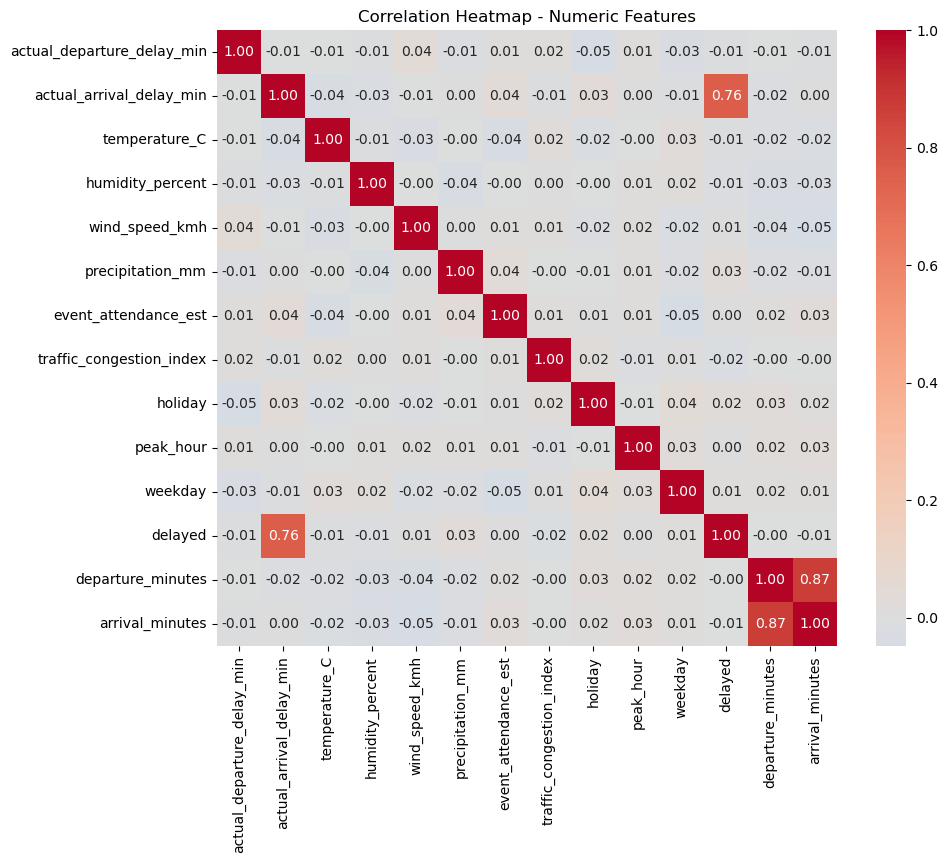

In [13]:
# Select numeric columns only
numeric_df = transport_delay_df.select_dtypes(include="number")

# Calculate correlations
full_corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    full_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap - Numeric Features")
plt.show()

## Selecting Features and Target

We now separate the dataset into the predictor variables (`X`) and the target variable (`y`).

The target variable is `delayed`, which indicates whether the journey is classified as delayed.

The selected features represent information that could potentially be available before or around the scheduled journey, including transport type, route, scheduled timing, weather, traffic, calendar information and events.

The actual departure and arrival delay variables are excluded because they describe what happened during the journey. Including them as predictors would introduce data leakage.

In [14]:
# Select the features (X) and the target (y)
X = transport_delay_df[
    [
        "transport_type",
        "route_id",
        "departure_minutes",
        "arrival_minutes",
        "weather_condition",
        "temperature_C",
        "humidity_percent",
        "wind_speed_kmh",
        "precipitation_mm",
        "traffic_congestion_index",
        "holiday",
        "peak_hour",
        "weekday",
        "season",
        "event_type",
        "event_attendance_est"
    ]
]

y = transport_delay_df["delayed"]
X.describe()

,departure_minutes,arrival_minutes,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,traffic_congestion_index,holiday,peak_hour,weekday,event_attendance_est
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,718.785000,723.38850,15.121350,64.714000,29.300500,9.860700,50.244000,0.089500,0.272000,2.976000,6420.250000
std,414.536045,415.02517,11.479424,20.334747,17.264015,5.781373,29.225751,0.285535,0.445101,1.990328,15198.306129
min,0.000000,0.00000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,362.750000,368.00000,5.100000,46.000000,15.000000,4.900000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,721.000000,725.50000,15.300000,65.000000,29.000000,9.700000,50.000000,0.000000,0.000000,3.000000,0.000000
75%,1081.000000,1082.25000,24.800000,83.000000,45.000000,14.800000,76.000000,0.000000,1.000000,5.000000,2000.000000
max,1429.000000,1439.00000,35.000000,99.000000,59.000000,20.000000,99.000000,1.000000,1.000000,6.000000,50000.000000


## Handling Missing Values in Event Type

The `event_type` column contains missing values. Instead of removing these rows, we treat the missing values as a separate category called `Unknown`.

This allows us to keep all available journeys in the dataset while allowing the One-Hot Encoder to process the missing information as a categorical value.

In [15]:
# Replace missing event types with "Unknown"
X = X.copy()
X["event_type"] = X["event_type"].fillna("Unknown")

In [16]:
X["event_type"].value_counts()

event_type
Unknown     1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

In [17]:
# Specify your categorical columns
categorical_columns = [
    "transport_type",
    "route_id",
    "weather_condition",
    "season",
    "event_type"
]

In [18]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(X[col].unique())


transport_type:
['Tram' 'Metro' 'Bus' 'Train']

route_id:
['Route_15' 'Route_12' 'Route_16' 'Route_19' 'Route_8' 'Route_17'
 'Route_5' 'Route_6' 'Route_18' 'Route_9' 'Route_13' 'Route_10' 'Route_7'
 'Route_14' 'Route_20' 'Route_3' 'Route_2' 'Route_11' 'Route_4' 'Route_1']

weather_condition:
['Storm' 'Rain' 'Clear' 'Snow' 'Fog' 'Cloudy']

season:
['Winter' 'Autumn' 'Spring' 'Summer']

event_type:
['Unknown' 'Sports' 'Protest' 'Parade' 'Concert' 'Festival']


In [19]:
# Step 2: Train / Test Split
# ---------------------------
# Split the data into training and testing sets. Stratification preserves the proportion of delayed and non-delayed journeys in both datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (1600, 16)
X_test shape:  (400, 16)


In [30]:
# N.B. Keep categorical columns in their original, non-one-hot form at this stage 
# (e.g. transport_type stays as "Bus" / "Train", not split into transport_type_Bus, transport_type_Train)

In [31]:
# Run SMOTENC on the raw unencoded training data, telling it which columns are categorical
#
# SMOTENC can handle numerical and categorical
# X_train still has the ORIGINAL categorical columns (not one-hot yet)
categorical_columns = ["transport_type", "route_id", "weather_condition", "season", "event_type"]
cat_indices = [X_train.columns.get_loc(col) for col in categorical_columns]

sm = SMOTENC(categorical_features=cat_indices, random_state=SEED)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

In [33]:
# Train the Model

smote_model = SGDClassifier(loss='log_loss', random_state=SEED)
smote_model.fit(X_train_final, y_train_smote)  # Fit on the SMOTE-resampled Train set

print("Model trained!")

Model trained!


In [34]:
# SMOTE Results

y_pred_train = smote_model.predict(X_train_final)
y_pred_test = smote_model.predict(X_test_final)

accuracy_train = accuracy_score(y_train_smote, y_pred_train)

print(f'Accuracy (Train): {accuracy_train * 100:.2f}%')
print()

print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Not Delayed', 'Delayed'],
    zero_division=0
))

Accuracy (Train): 48.00%

              precision    recall  f1-score   support

 Not Delayed       0.26      0.41      0.32       100
     Delayed       0.75      0.60      0.67       300

    accuracy                           0.56       400
   macro avg       0.51      0.51      0.49       400
weighted avg       0.63      0.56      0.58       400



## SMOTENC Results Analysis

Earlier, we used SMOTE to fix the imbalance between delayed and non-delayed journeys in the training data. However, SMOTE isn't designed for categorical (one-hot encoded) columns — it creates new data points by averaging existing ones, which doesn't make sense for category columns like transport type. This can produce made-up, invalid values that don't represent real categories.

To fix this, we switched to SMOTENC, a version of SMOTE built to handle a mix of numerical and categorical features. It still creates new numeric values by averaging, but for categorical columns, it copies real category values instead of averaging them. This keeps the synthetic data realistic.

After retraining the model with SMOTENC, it reached a training accuracy of 48% and a test accuracy of 56%.

For Not Delayed journeys, the model correctly identified 41% of them (recall), but only 26% of its "Not Delayed" predictions were actually correct (precision).

For Delayed journeys, the model correctly identified 60% of them (recall), and 75% of its "Delayed" predictions were correct (precision).

This is a big improvement compared to the earlier SMOTE version, where the model was heavily biased toward guessing one class almost all the time. Now, the model is making real attempts to tell the two classes apart, and both classes have reasonable (non-zero) precision and recall. The overall balance between classes, measured using macro F1-score, came out to 0.49.

That said, the model's overall performance is still fairly weak — a macro F1-score of 0.49 is only a little better than random guessing would give. This matches what we saw earlier when exploring the data: features like traffic congestion, temperature, and precipitation showed only small differences between delayed and non-delayed journeys. 

This suggests the current features may not contain enough useful information to strongly predict delays, even with a correct modelling process. Going forward, it would be worth trying more powerful models like Random Forest or XGBoost on this corrected data, and considering whether new or different features could help the model perform better.

In [35]:
# NOW one-hot encode the balanced training data
encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")
X_train_encoded = encoder.fit_transform(X_train_smote[categorical_columns])
X_test_encoded = encoder.transform(X_test[categorical_columns])

# combine with numeric columns as before, but using X_train_smote instead of X_train

In [36]:
# Select the numerical features
numerical_columns = [
    "departure_minutes",
    "arrival_minutes",
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "weekday",
    "event_attendance_est"
]

X_train_numerical_df = X_train_smote[numerical_columns].copy()
X_test_numerical_df = X_test[numerical_columns].copy()

In [37]:
# Get the resulting column names
encoded_cols = encoder.get_feature_names_out(
    categorical_columns
)

# Create readable DataFrames
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train_smote.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

X_train_encoded_df.head()

,transport_type_Metro,transport_type_Train,transport_type_Tram,route_id_Route_10,route_id_Route_11,route_id_Route_12,route_id_Route_13,route_id_Route_14,route_id_Route_15,route_id_Route_16,...,weather_condition_Snow,weather_condition_Storm,season_Spring,season_Summer,season_Winter,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [38]:
# Combine encoded categorical features with numerical features

X_train_final = pd.concat(
    [X_train_numerical_df, X_train_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_numerical_df, X_test_encoded_df],
    axis=1
)

In [39]:
X_train_final.head()

,departure_minutes,arrival_minutes,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,traffic_congestion_index,holiday,peak_hour,weekday,...,weather_condition_Snow,weather_condition_Storm,season_Spring,season_Summer,season_Winter,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown
0,752,792,30.4,61,34,16.7,92,0,0,4,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1006,1053,-1.7,68,22,1.9,52,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,78,96,-4.0,37,15,15.4,93,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,799,850,22.8,43,13,10.0,73,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1036,1088,-4.5,59,23,7.7,23,0,0,5,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [40]:
X_train_final.shape

(2398, 46)

## Checking for Missing Values

After handling the missing values in `event_type`, we check the remaining numerical features for missing values.

The numerical features contain no missing values, so no additional imputation is required at this stage.

In [41]:
# Check the final training and testing datasets for missing values

print("Missing values in X_train_final:")
print(X_train_final.isnull().sum().sum())

print("\nMissing values in X_test_final:")
print(X_test_final.isnull().sum().sum())

Missing values in X_train_final:
0

Missing values in X_test_final:
0


## Checking the Final Dataset

After handling missing values and completing the feature encoding, we check the final training and testing datasets for any remaining missing values.

Both datasets contain no missing values, so they are ready for modelling.

In [45]:
# Model Training: Random Forest Classifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=2,      # deliberately small subset per split, to reduce correlation between trees
    random_state=SEED)

rf_clf.fit(X_train_final, y_train_smote)
print("Model Trained!")

Model Trained!


In [46]:
# Random Forest Results

y_pred_train = rf_clf.predict(X_train_final)     # predicting on the encoded training data
y_pred_test = rf_clf.predict(X_test_final)         # predicting on the encoded test data

acc_train = accuracy_score(y_train_smote, y_pred_train)   # compared against balanced training labels
acc_test = accuracy_score(y_test, y_pred_test)             # compared against real test labels

print(f'Accuracy (Train): {acc_train * 100:.2f}%')
print(f'Accuracy (Test): {acc_test * 100:.2f}%')
print()

print('Classification Report (Test):')
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Not Delayed", "Delayed"],
    zero_division=0
))  # real labels vs. real predictions

Accuracy (Train): 97.00%
Accuracy (Test): 64.50%

Classification Report (Test):
              precision    recall  f1-score   support

 Not Delayed       0.28      0.27      0.28       100
     Delayed       0.76      0.77      0.76       300

    accuracy                           0.65       400
   macro avg       0.52      0.52      0.52       400
weighted avg       0.64      0.65      0.64       400



## Random Forest with SMOTENC: Results Analysis

The Random Forest model was trained on the SMOTENC-balanced training data and evaluated on the original, untouched test data.

The model achieved a training accuracy of 97.00%, but a much lower test accuracy of 64.50%. This large gap between training and test performance is a sign of overfitting — the model has essentially memorised patterns in the training data, including noise and small quirks, rather than learning patterns general enough to apply well to new, unseen data.

For the Not Delayed class, the model achieved a recall of 27% and a precision of 28%, meaning it missed most non-delayed journeys and was often wrong when it did predict "Not Delayed."

For the Delayed class, the model achieved a recall of 77% and a precision of 76%, showing it is considerably better at identifying delayed journeys than non-delayed ones.

The macro F1-score was 0.52, a small improvement over the SGDClassifier's 0.49, but the model is once again leaning more heavily toward predicting "Delayed," similar to the imbalance issue seen earlier, just less extreme.

This overfitting is likely due to the current hyperparameters allowing the trees to grow too flexible: min_samples_split=5 and min_samples_leaf=2 allow splits on very small groups of data, and max_features=2 was originally chosen for a much smaller set of raw features (6), but the feature set is now far larger after one-hot encoding, so it no longer limits complexity in the way it was intended to.

This result is also consistent with earlier exploratory analysis, which found only small differences in key numerical features (e.g. traffic congestion, temperature, precipitation) between delayed and non-delayed journeys. With relatively weak underlying signal in the data, a flexible model like Random Forest can end up fitting to noise rather than genuine patterns, producing exactly this kind of high-train/low-test accuracy gap.

The next step will be to use RandomizedSearchCV to search for hyperparameters that better constrain the trees (e.g. adjusting min_samples_leaf, min_samples_split, and max_depth) to reduce overfitting, and to score the search using f1_macro so that hyperparameter selection rewards balanced performance across both classes rather than favouring the majority "Delayed" class.

## Random forest Ensemble with Random Search Cross Validation

In [50]:
# Random Forest Ensemble Method with RandomizedSearchCV
# ------------------------------------------------------

# 1. Define the hyperparameter search space
random_search = {
    'n_estimators': [100, 200, 300, 500],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5, 10, 20],
    'max_depth': [3, 5, 10],
    'max_features': ['sqrt', 'log2', 2, 3]
}

# 2. Create the Random Forest model
rf_clf = RandomForestClassifier(
    random_state=SEED
)

# 3. Set up RandomizedSearchCV
model = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=random_search,
    n_iter=10,
    cv=4,
    random_state=SEED,
    n_jobs=-1,
    scoring='f1_macro'
)

# 4. Fit the model using the SMOTE-balanced training data
model.fit(X_train_final, y_train_smote)

print("Model Trained!")

Model Trained!


In [51]:
# Randomized Search CV Results

# Best combination found by Random Search

print("Best hyperparameters found:")
print(model.best_params_)
print()

# Best Random Forest model
best_rf = model.best_estimator_

# Predictions on training and test data
y_pred_train = best_rf.predict(X_train_final)
y_pred_test = best_rf.predict(X_test_final)

# Calculate accuracy
accuracy_train = accuracy_score(y_train_smote, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy (Train): {accuracy_train * 100:.2f}%")
print(f"Accuracy (Test): {accuracy_test * 100:.2f}%")
print()

# Classification Report
print("Classification Report (Test):")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Not Delayed", "Delayed"],
    zero_division=0
))

Best hyperparameters found:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10}

Accuracy (Train): 83.78%
Accuracy (Test): 61.50%

Classification Report (Test):
              precision    recall  f1-score   support

 Not Delayed       0.24      0.24      0.24       100
     Delayed       0.74      0.74      0.74       300

    accuracy                           0.61       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.62      0.61      0.62       400



## Random Forest with Constrained RandomizedSearchCV: Results Analysis

Following the earlier finding that Random Forest was overfitting the training data, the hyperparameter search space was narrowed to encourage simpler, less flexible trees. min_samples_leaf values of 1 and 2 were removed, and a max_depth constraint was introduced. The best combination found was:

n_estimators = 100
min_samples_split = 5
min_samples_leaf = 5
max_features = 'sqrt'
max_depth = 10

This model achieved a training accuracy of 83.78% and a test accuracy of 61.50%. Compared with the previous tuned model (100% train / 65% test), the gap between training and test accuracy has narrowed considerably, confirming that these more conservative hyperparameters <b>successfully reduced overfitting</b>.

For the Not Delayed class, the model achieved a recall of 24% and a precision of 24%.

For the Delayed class, the model achieved a recall of 74% and a precision of 74%.

The macro F1-score was 0.49, slightly lower than the earlier overfit models (0.51–0.52). This is an important result: reducing overfitting did not improve overall test performance, and if anything, test performance was marginally lower. This indicates that the strong training accuracy seen in previous models was not reflecting genuine predictive ability that had simply been "hidden" by overfitting — rather, once the model was prevented from memorising the training data, its underlying ability to distinguish delayed from non-delayed journeys remained largely unchanged.

This finding reinforces the conclusion drawn from earlier exploratory analysis, where key numerical features (traffic congestion, temperature, precipitation, etc.) showed only small differences between delayed and non-delayed journeys. Constraining the Random Forest's complexity did not come at a meaningful cost to test performance, which suggests there was limited genuine signal for the additional model complexity to exploit in the first place.

Taken together, these results suggest that further hyperparameter tuning of Random Forest is unlikely to substantially improve performance on this dataset. The next step will be to compare these results against XGBoost, to evaluate whether a different model architecture can extract additional predictive signal from the existing features, while keeping in mind that the limitation may lie in the feature set itself rather than the choice of model.

In [52]:
# XGBoost Baseline
# -------------------------

# Initialize the XGBoost classifier

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=SEED,
    eval_metric="logloss"
)

# Train XGBoost 

xgb_model.fit(
    X_train_final,
    y_train_smote
)

print("XGBoost model training complete!")

XGBoost model training complete!


In [53]:
# XGBoost Results
# ------------------------

# Predictions

y_pred_train = xgb_model.predict(X_train_final)
y_pred_test = xgb_model.predict(X_test_final)

# Accuracy

accuracy_train = accuracy_score(y_train_smote, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy (Train): {accuracy_train * 100:.2f}%")
print(f"Accuracy (Test): {accuracy_test * 100:.2f}%")
print()

# Classification Report

print("Classification Report (Test):")

print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Not Delayed", "Delayed"],
    zero_division=0
))

Accuracy (Train): 78.11%
Accuracy (Test): 60.25%

Classification Report (Test):
              precision    recall  f1-score   support

 Not Delayed       0.27      0.34      0.30       100
     Delayed       0.76      0.69      0.72       300

    accuracy                           0.60       400
   macro avg       0.51      0.52      0.51       400
weighted avg       0.64      0.60      0.62       400



## Step 4 - XGBoost Baseline: Results Analysis

The baseline XGBoost model was trained using the SMOTENC-balanced training data and evaluated on the original, untouched test dataset, using a deliberately shallow max_depth=3 to limit overfitting.

The model achieved a training accuracy of 78.11% and a test accuracy of 60.25%. The relatively small gap between training and test accuracy (compared with the Random Forest models) suggests this baseline is not overfitting as severely.

For the Not Delayed class, the model achieved a recall of 34% and a precision of 27%. This is the best recall achieved for this class across all models tested so far.

For the Delayed class, the model achieved a recall of 69% and a precision of 76%.

The macro F1-score was 0.51, in line with the best Random Forest result (0.52) and higher than the more heavily overfit Random Forest configurations. This suggests XGBoost is achieving a similar, or marginally better, level of class balance than Random Forest, while doing so with noticeably less overfitting.

Across all three models tested so far — SGDClassifier, Random Forest, and this XGBoost baseline — macro F1-scores have consistently landed in a narrow range of approximately 0.49 to 0.52, despite substantial differences in model complexity and tuning. This consistency across different model architectures reinforces the conclusion drawn from exploratory analysis: the available features appear to carry limited predictive signal for distinguishing delayed from non-delayed journeys, and this limitation is not specific to any one model choice.

The next step will be to apply GridSearchCV to XGBoost to determine whether further hyperparameter tuning can extract additional performance, while bearing in mind that a similar ceiling to the one observed with Random Forest is expected given the consistency of results so far.

In [54]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
xgb_model = xgb.XGBClassifier(
    random_state=SEED,
    eval_metric="logloss"
)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=4,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train_smote)

print("XGBoost Grid Search complete!")
print("Best parameters:")
print(grid_search.best_params_)
print(f"Best CV Macro F1: {grid_search.best_score_:.4f}")

XGBoost Grid Search complete!
Best parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV Macro F1: 0.7479


In [55]:
# XGBoost Grid Search CV Results
# ---------------------------------------

# Best hyperparameters found by Grid Search

print("Best hyperparameters found:")
print(grid_search.best_params_)
print()

# Best XGBoost model

best_xgb = grid_search.best_estimator_

# Predictions on training and test data

y_pred_train = best_xgb.predict(X_train_final)
y_pred_test = best_xgb.predict(X_test_final)

# Calculate accuracy

accuracy_train = accuracy_score(y_train_smote, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f"Accuracy (Train): {accuracy_train * 100:.2f}%")
print(f"Accuracy (Test): {accuracy_test * 100:.2f}%")
print()

# Classification Report

print("Classification Report (Test):")

print(classification_report(
    y_test,
    y_pred_test,
    target_names=["Not Delayed", "Delayed"],
    zero_division=0
))

Best hyperparameters found:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}

Accuracy (Train): 100.00%
Accuracy (Test): 65.00%

Classification Report (Test):
              precision    recall  f1-score   support

 Not Delayed       0.27      0.24      0.26       100
     Delayed       0.76      0.79      0.77       300

    accuracy                           0.65       400
   macro avg       0.51      0.51      0.51       400
weighted avg       0.64      0.65      0.64       400



## XGBoost GridSearchCV: Results Analysis

GridSearchCV was used with 4-fold cross-validation and f1_macro scoring to search for an XGBoost configuration offering the best balance between the two classes. The best combination found was:

learning_rate = 0.1<br>
max_depth = 7<br>
n_estimators = 300<br>
subsample = 0.8<br>


This tuned model achieved a training accuracy of 100.00% and a test accuracy of 65.00%. As with the tuned Random Forest models, the 100% training accuracy indicates the model has fully memorised the training data, and the large train-test gap confirms that this configuration overfits, despite subsample=0.8 being included specifically to help mitigate this.

For the Not Delayed class, the model achieved a recall of 24% and a precision of 27%.

For the Delayed class, the model achieved a recall of 79% and a precision of 76%.

The macro F1-score was 0.51, essentially unchanged from the untuned XGBoost baseline (0.51) and consistent with the range achieved by the best Random Forest models (0.49–0.52). As with Random Forest, increasing model flexibility through tuning improved training accuracy substantially but did not translate into better generalisation to the test set.

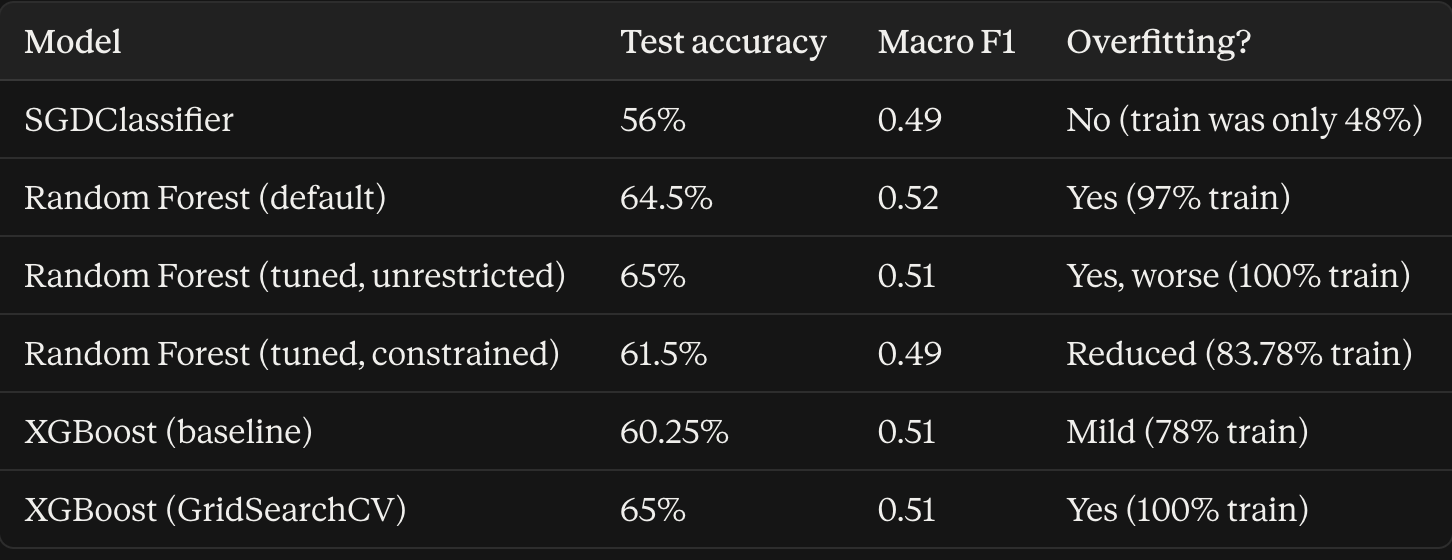

## Overall Conclusion

Across three different model architectures — SGDClassifier, Random Forest, and XGBoost — and multiple tuning approaches (default parameters, RandomizedSearchCV, GridSearchCV, and manually constrained hyperparameter ranges), test set performance consistently converged on a macro F1-score of approximately 0.49–0.52. This range is only marginally better than what would be expected from random guessing when both classes are weighted equally.

Two methodological issues were identified and corrected during this project:

SMOTE was initially applied after one-hot encoding, which is invalid for categorical features since SMOTE interpolates linearly between data points. This was corrected by switching to SMOTENC, applied before encoding, which resamples categorical features using real observed values rather than interpolated ones.
RandomizedSearchCV initially used 'f1' scoring, which only measures performance on the majority "Delayed" class. This was corrected to 'f1_macro', ensuring hyperparameter selection rewards balanced performance across both classes.

Correcting these issues improved the validity of the modelling pipeline and reduced the extreme class bias seen in early models (where "Not Delayed" recall was close to 0%). However, it did not meaningfully improve overall predictive performance. Additionally, allowing models more flexibility (e.g. deeper trees, more estimators) consistently increased training accuracy toward 100% without improving test performance — a clear sign of overfitting rather than genuine learning.

This consistency across model types, tuning strategies, and levels of model complexity strongly suggests that the limitation lies in the available features, not in model choice or configuration. This is supported by the earlier exploratory analysis, which found only small differences in key numerical features (traffic congestion, temperature, humidity, precipitation, event attendance) between delayed and non-delayed journeys.